In [1]:
# start by loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Packages loaded successfully")

Packages loaded successfully


In [2]:
# read the EPA data
#df = pd.read_csv('HABsDrivers_Model_Data.csv')
df = pd.read_csv("../data/HABsDrivers_Model_Data.csv")
print(' Data loaded successfully')

 Data loaded successfully


### Start with understanding the data. What actuallly I have?

In [3]:
df.shape


(3664, 72)

In [4]:
df.head()

,SITE_ID,VISIT_NO,UNIQUE_ID,DSGN_CYCLE,DATE_COL,LAT_DD83,LON_DD83,COMID,TEMPERATURE,MAXDEPTH,...,P_f_fertilizer,P_human_waste_kg,P_livestock_Waste,P_nf_fertilizer,n_farm_inputs,n_dev_inputs,p_farm_inputs,p_dev_inputs,AG_ECO3,AG_ECO9_NM
0,NLA12_CA-143,1,NLA_CA-10078,2012,05/02/2012,37.564489,-121.997182,2806117,12.00,7.8,...,0.00,29.06,0.00,2.46,0.00,NaN,0.00,31.52,WMTNS,Xeric
1,NLA12_AZ-101,1,NLA_AZ-10016,2012,05/08/2012,33.569297,-111.524143,20476542,21.53,24.0,...,0.02,0.03,0.16,0.00,0.68,0.13,0.18,0.03,WMTNS,Xeric
2,NLA12_ND-115,1,NLA_ND-10055,2012,05/16/2012,46.826042,-100.634208,14681240,17.01,8.0,...,0.00,0.06,4.14,0.23,71.36,1.60,4.14,0.29,PLNLOW,Northern Plains
3,NLA12_AZ-118,1,NLA_AZ-10057,2012,05/09/2012,33.381311,-111.883581,20479908,24.80,0.0,...,0.05,10.07,2.99,0.18,43.71,192.28,3.04,10.25,WMTNS,Xeric
4,NLA12_UT-103,1,NLA_UT-10023,2012,05/09/2012,41.518822,-111.736433,664040,12.30,33.5,...,0.01,0.09,0.02,0.01,0.17,0.55,0.03,0.10,WMTNS,Western Mountains


### Read the metadata

In [5]:
# now load the meta data:
metadata = pd.read_csv("../data/HABsDrivers_Model_Metadata.csv")
print('Meta data loaded successfully')

Meta data loaded successfully


In [6]:
metadata.shape
metadata.head()


,Variable,Description,Type,Values,Units,MissingDataValue,MissingDataMeaning
0,SITE_ID,A site ID assigned to a lake within an NLA sur...,character,NaN,NaN,NaN,NaN
1,VISIT_NO,The first or second visit to a site,integer,1 | 2,NaN,NaN,NaN
2,UNIQUE_ID,A unique ID assigned to each lake sampled acro...,character,NaN,NaN,NaN,NaN
3,DSGN_CYCLE,The year of the NLA survey cycle,integer,2007 | 2012 | 2017,NaN,NaN,NaN
4,DATE_COL,Date sample was collected,date,NaN,M/D/YYYY,NaN,NaN


In [7]:
#Inspect the columns
df.columns.tolist()

['SITE_ID',
 'VISIT_NO',
 'UNIQUE_ID',
 'DSGN_CYCLE',
 'DATE_COL',
 'LAT_DD83',
 'LON_DD83',
 'COMID',
 'TEMPERATURE',
 'MAXDEPTH',
 'STRATIFIED',
 'AMMONIA_N',
 'DO_SURF',
 'DOC',
 'NTL',
 'PTL',
 'TURB',
 'NITRATE_N',
 'PH',
 'CHLA_RESULT',
 'MICX',
 'MICX_DET',
 'B_G_DENS',
 'EVAP_INFL',
 'D_EXCESS',
 'agr_ws',
 'dev_ws',
 'fst_ws',
 'wet_ws',
 'precip_mean_month',
 'temp_mean_month',
 'lakemorpho_fetch',
 'BFIWs',
 'AgKffactWs',
 'KffactWs',
 'RunoffWs',
 'Precip_Minus_EVTWs',
 'Precip8110Ws',
 'Tmean8110Ws',
 'ElevWs',
 'SlopeWs',
 'N_CBNF',
 'N_Crop_N_Rem',
 'N_Fert_Farm',
 'N_Fert_Urban',
 'N_Forest_Fire',
 'N_Human_N_Demand',
 'N_Human_Waste',
 'N_Manure_Recov',
 'N_Rock',
 'N_Surplus',
 'N_Total_Deposition',
 'N_Total_Inputs',
 'N_Total_Outputs',
 'N_Total_nBNF',
 'N_livestock_Waste',
 'P_Accumulated_ag_inputs',
 'P_Crop_removal',
 'P_Deposition',
 'P_Legacy_P',
 'P_Recovered_P',
 'P_Surplus',
 'P_f_fertilizer',
 'P_human_waste_kg',
 'P_livestock_Waste',
 'P_nf_fertilizer',
 '

### SCheck data types and missing values

In [8]:
#SCheck data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3664 entries, 0 to 3663
Data columns (total 72 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SITE_ID                  3664 non-null   str    
 1   VISIT_NO                 3664 non-null   int64  
 2   UNIQUE_ID                3664 non-null   str    
 3   DSGN_CYCLE               3664 non-null   int64  
 4   DATE_COL                 3664 non-null   str    
 5   LAT_DD83                 3664 non-null   float64
 6   LON_DD83                 3664 non-null   float64
 7   COMID                    3664 non-null   int64  
 8   TEMPERATURE              3620 non-null   float64
 9   MAXDEPTH                 3632 non-null   float64
 10  STRATIFIED               3664 non-null   int64  
 11  AMMONIA_N                3663 non-null   float64
 12  DO_SURF                  3611 non-null   float64
 13  DOC                      3655 non-null   float64
 14  NTL                      3664 non-n

In [9]:
df.isna().sum() #this line is to calculate the missing value

SITE_ID            0
VISIT_NO           0
UNIQUE_ID          0
DSGN_CYCLE         0
DATE_COL           0
                ... 
n_dev_inputs     565
p_farm_inputs    574
p_dev_inputs     572
AG_ECO3            0
AG_ECO9_NM         0
Length: 72, dtype: int64

### The question I want to answer is which environmental factors are associated with the cyanobacterial abundance in U.S. lakes?


## To start with, I will choose four potential explanatory variable and one outcome, namely:
### 1: Cyanobacteria density (B_G_DENS)
### 2: Water temperature (TEMPERATURE)
### 3: Total phosphorus (PTL)
### 4: Total nitrogen (NTL)
### 5: Chlorophyll-a (CHLA_RESULT)
### The table below gives more information

| Variable      | Role        | Why                   |
| ------------- | ----------- | --------------------- |
| `B_G_DENS`    | **Outcome** | Cyanobacteria density |
| `TEMPERATURE` | Predictor   | Water temperature     |
| `PTL`         | Predictor   | Total phosphorus      |
| `NTL`         | Predictor   | Total nitrogen        |
| `CHLA_RESULT` | Predictor   | Chlorophyll-a         |


In [10]:
# Let's select these variable from the DataFrame
sel_var = [
    'B_G_DENS',
    'TEMPERATURE',
    'PTL',
    'NTL',
    'CHLA_RESULT'
]


In [11]:
# now investigate them:

df[sel_var].head()

,B_G_DENS,TEMPERATURE,PTL,NTL,CHLA_RESULT
0,2158.0,12.00,26.8,0.339,2.700
1,7319.0,21.53,40.0,0.321,3.228
2,3599.0,17.01,70.0,1.509,7.480
3,0.0,24.80,38.0,0.483,1.300
4,45.0,12.30,23.0,0.189,6.353


In [12]:
df[sel_var].info()

<class 'pandas.DataFrame'>
RangeIndex: 3664 entries, 0 to 3663
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   B_G_DENS     3661 non-null   float64
 1   TEMPERATURE  3620 non-null   float64
 2   PTL          3659 non-null   float64
 3   NTL          3664 non-null   float64
 4   CHLA_RESULT  3653 non-null   float64
dtypes: float64(5)
memory usage: 143.3 KB


In [13]:
df[sel_var].describe()

,B_G_DENS,TEMPERATURE,PTL,NTL,CHLA_RESULT
count,3.661000e+03,3620.000000,3659.000000,3664.000000,3653.000000
mean,2.161805e+05,23.859354,110.714694,1.124314,27.531446
std,1.028627e+06,4.382657,321.115279,2.068816,79.959188
min,0.000000e+00,0.800000,1.000000,0.010000,0.066000
25%,2.448000e+03,21.137500,14.822500,0.329000,2.968000
50%,1.970000e+04,24.200000,33.558750,0.616000,7.970000
75%,9.410000e+04,27.000000,92.000000,1.216750,25.440000
max,3.882800e+07,37.630000,11238.800000,54.000000,3299.180000


### The output shows 3664 entries, 0 to 3663
### let check for missing value, if any

In [14]:
df[sel_var].isna().sum()

B_G_DENS        3
TEMPERATURE    44
PTL             5
NTL             0
CHLA_RESULT    11
dtype: int64

### The missing values are very small: That's excellent for the analysisthere is no  serious missing-data problem.

### For the five variables together, we'll only lose a small number of rows if we eventually use complete-case analysis.

In [15]:
df['B_G_DENS'].sort_values(ascending=False).head(20)

3626    38828000.0
3407    19836230.0
3244    16568000.0
3371    12430260.0
2498     9925840.0
1071     8757487.0
3604     8655300.0
1025     8493252.0
3641     8045670.0
2993     7300700.0
715      6766108.0
3414     6535340.0
2709     6066680.0
3508     6051620.0
2681     5890342.0
748      5796307.0
2873     5777440.0
3620     5420540.0
2832     5310792.0
3587     5161900.0
Name: B_G_DENS, dtype: float64

### Now I will investigate the actual distribution using histogram

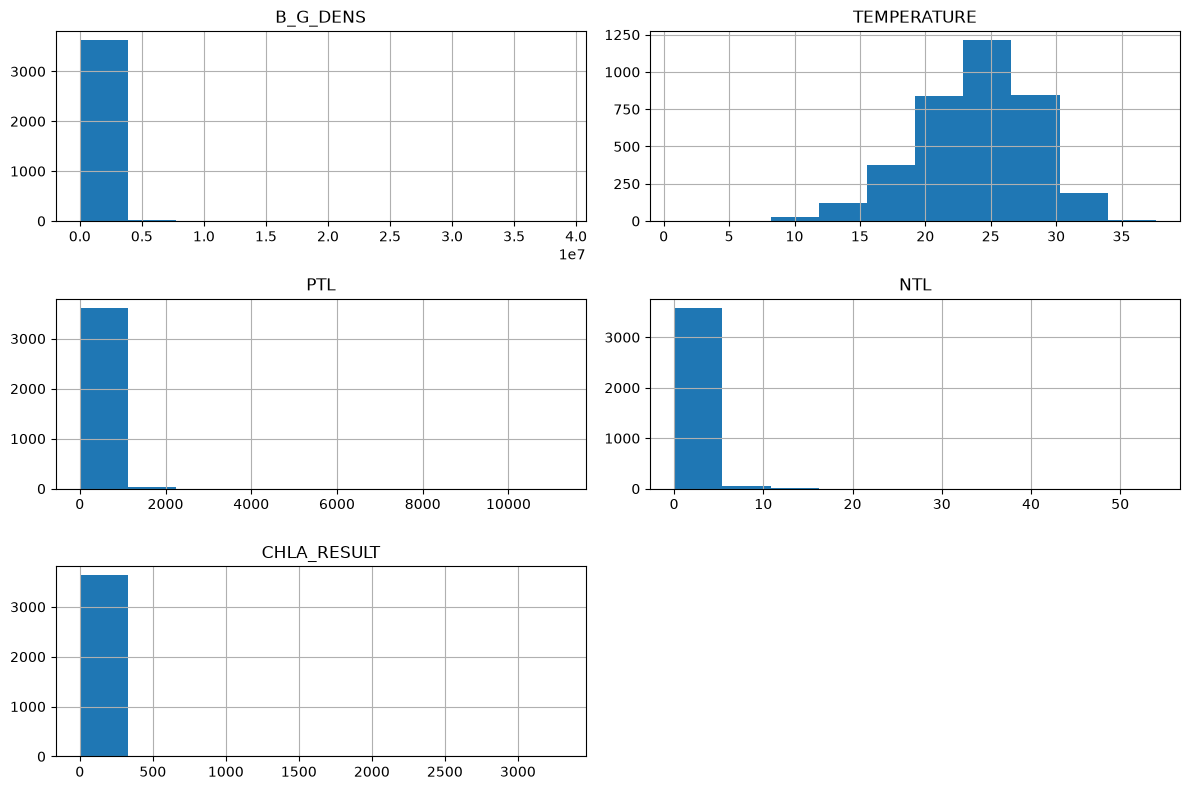

In [16]:
df[sel_var].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### The figures look extremely skewed
### let's look at each distribution closely

## Let's make your first important plot.

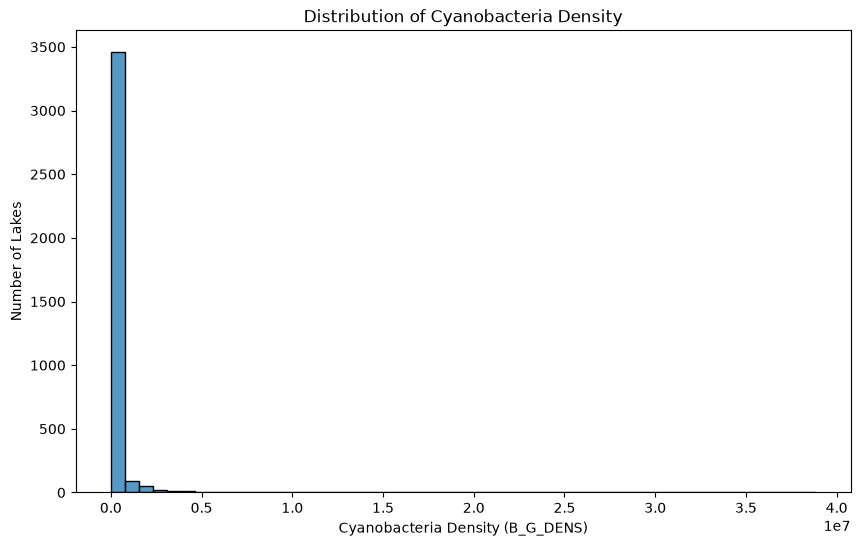

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='B_G_DENS',
    bins=50
)

plt.title('Distribution of Cyanobacteria Density')
plt.xlabel('Cyanobacteria Density (B_G_DENS)')
plt.ylabel('Number of Lakes')

plt.show()

### It can be see most observations compressed toward the left because of the extreme values.
### This confirm when we compare the median with the maximum:
### 19,700 → 38,828,000

### What the histogram show us
### Most of the 3,664 lake observations are concentrated at relatively low B_G_DENS values.
### A small number of observations have very large cyanobacteria densities.
### The x-axis extends to roughly 40 million, which causes the majority of observations to be compressed near zero.
### This is why the ordinary histogram isn't very useful for seeing the detailed distribution of most lakes.
### An interesting findingThat's actually a useful finding. let's look into log scale

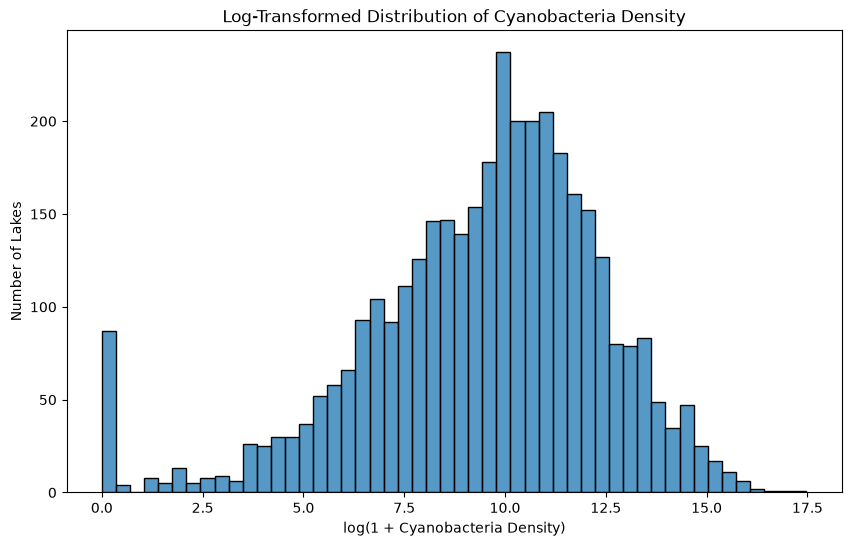

In [18]:
df['B_G_DENS_log'] = np.log1p(df['B_G_DENS']) # this is to avoid log (0) that may occur from zero values
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='B_G_DENS_log',
    bins=50
)

plt.title('Log-Transformed Distribution of Cyanobacteria Density')
plt.xlabel('log(1 + Cyanobacteria Density)')
plt.ylabel('Number of Lakes')

plt.show()

### What can be seen The log transformation has compressed the extreme values and revealed the underlying distribution.

## A few observations stand out:

### 1: Most observations are now visible rather than being compressed against zero.
### 2: The main distribution is centered roughly around log(1 + B_G_DENS) = 10–12.
### 3: There is still a group at 0, representing lakes where B_G_DENS = 0.
### 4: There are some lower-density observations between roughly 1–5.
### 5: The distribution is much closer to a roughly bell-shaped distribution, although it isn't perfectly normal.

### This is a strong reason to use B_G_DENS_log for visualizations and correlation analysis, while keeping the original B_G_DENS for interpretation.

In [19]:
### Important distinction

## I haven't "fixed" the data by transforming it. I created another variable:

df['B_G_DENS_log'] = np.log1p(df['B_G_DENS'])

## So we still have:

## B_G_DENS       → original scientific measurement
## B_G_DENS_log   → transformed variable for analysis/visualization

### Let's plot the other varible

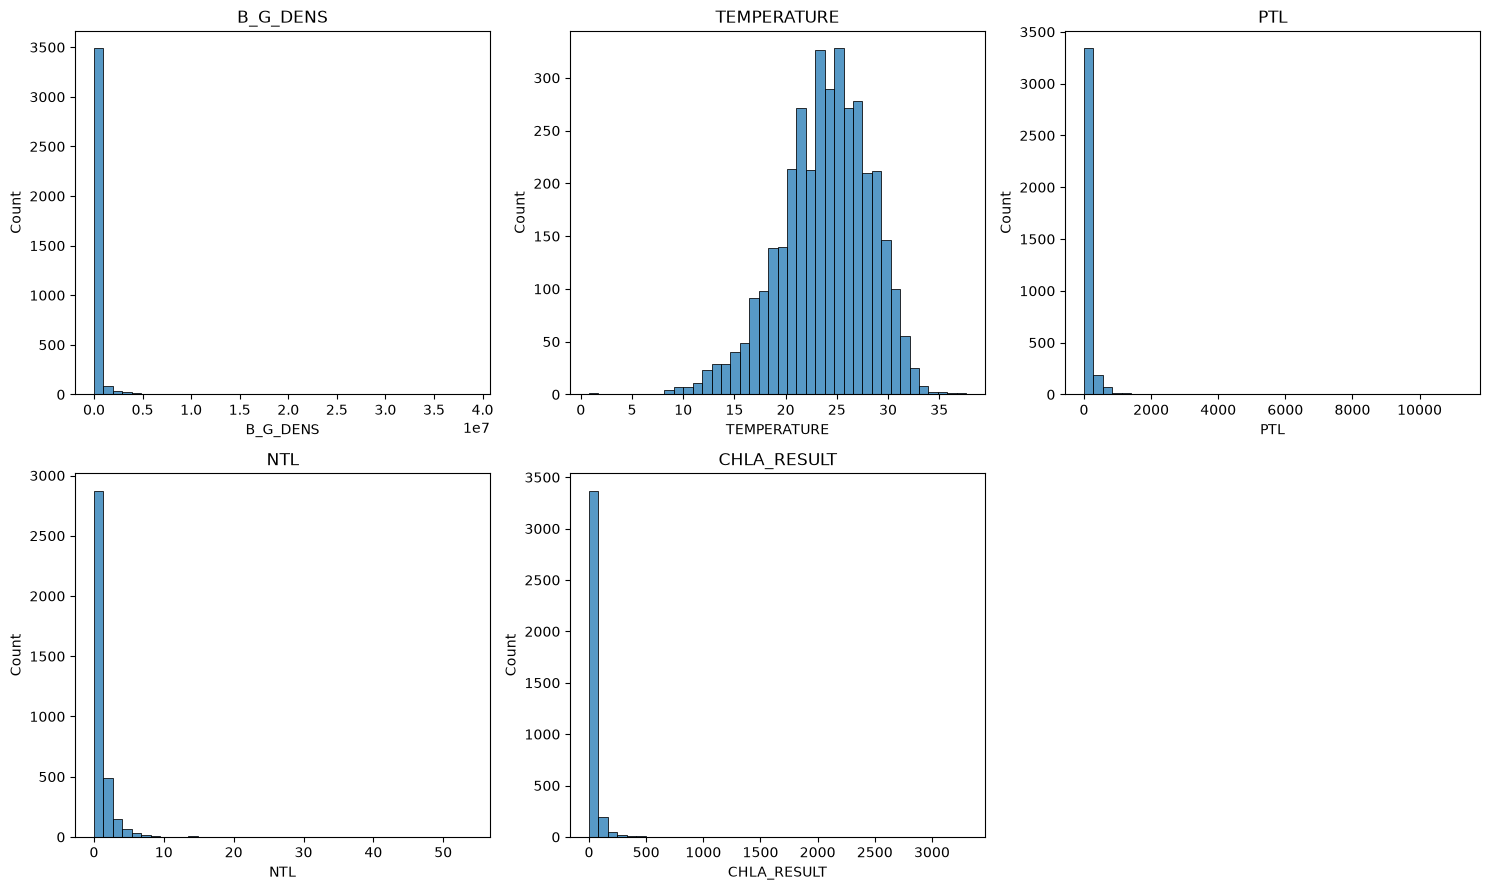

In [20]:


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, variable in zip(
    axes.flatten(),
    ['B_G_DENS', 'TEMPERATURE', 'PTL', 'NTL', 'CHLA_RESULT']
):
    sns.histplot(data=df, x=variable, bins=40, ax=ax)
    ax.set_title(variable)

axes[-1, -1].axis('off')

plt.tight_layout()
plt.show()

### The figures show that the varliables are right-skewed except the tempterature,
### Let perform the long transform and plot the results *_-


In [21]:
df['PTL_log'] = np.log1p(df['PTL'])
df['NTL_log'] = np.log1p(df['NTL'])
df['CHLA_RESULT_log'] = np.log1p(df['CHLA_RESULT'])

In [22]:
# run the check
df[['PTL', 'PTL_log', 'NTL', 'NTL_log', 'CHLA_RESULT', 'CHLA_RESULT_log']].describe()

,PTL,PTL_log,NTL,NTL_log,CHLA_RESULT,CHLA_RESULT_log
count,3659.000000,3659.000000,3664.000000,3664.000000,3653.000000,3653.000000
mean,110.714694,3.683897,1.124314,0.606044,27.531446,2.397913
std,321.115279,1.327558,2.068816,0.459262,79.959188,1.278158
min,1.000000,0.693147,0.010000,0.009950,0.066000,0.063913
25%,14.822500,2.761432,0.329000,0.284427,2.968000,1.378262
50%,33.558750,3.542661,0.616000,0.479954,7.970000,2.193886
75%,92.000000,4.532599,1.216750,0.796042,25.440000,3.274878
max,11238.800000,9.327216,54.000000,4.007333,3299.180000,8.101732


### plot the transform dist.


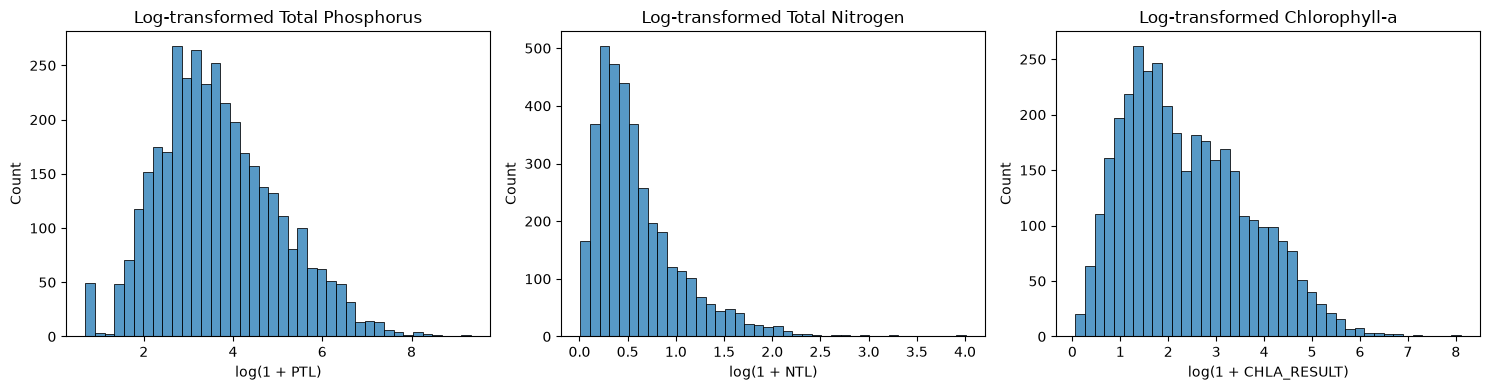

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['PTL_log'].dropna(), bins=40, ax=axes[0])
axes[0].set_title('Log-transformed Total Phosphorus')
axes[0].set_xlabel('log(1 + PTL)')

sns.histplot(df['NTL_log'].dropna(), bins=40, ax=axes[1])
axes[1].set_title('Log-transformed Total Nitrogen')
axes[1].set_xlabel('log(1 + NTL)')

sns.histplot(df['CHLA_RESULT_log'].dropna(), bins=40, ax=axes[2])
axes[2].set_title('Log-transformed Chlorophyll-a')
axes[2].set_xlabel('log(1 + CHLA_RESULT)')

plt.tight_layout()
plt.show()

### We have obtained useful information

 | Variable      | Original                   | After `log1p()`                  | Decision               |
 | ------------- | -------------------------- | -------------------------------- | ---------------------- |
 | `B_G_DENS`    | Very strongly right-skewed | Much more balanced               | **Use log**            |
 | `PTL`         | Right-skewed               | Approximately normal-ish         | **Use log**            |
 | `NTL`         | Right-skewed               | Still right-skewed               | **Keep investigating** |
 | `CHLA_RESULT` | Strongly right-skewed      | Improved, but still right-skewed | **Use log**            |
 | `TEMPERATURE` | Approximately normal       | —                                | **Keep original**      |

#### For NTL, I wouldn'tapply another transformation. The fact that it remains skewed is itself a characteristic of the environmental data.


### Now, I will quantify the skewness rather than relying only on visual interpretation.
### As a rough guide:

### 0 → symmetric
### positive → right-skewed
### negative → left-skewed
### around -0.5 to +0.5 → often considered reasonably symmetric
### 1 → substantially right-skewed

In [24]:
# This code will calculate the skewness value for each var.
selected_transformed = [
    'B_G_DENS_log',
    'PTL_log',
    'NTL_log',
    'CHLA_RESULT_log',
    'TEMPERATURE'
]

df[selected_transformed].skew()

B_G_DENS_log      -0.835335
PTL_log            0.451619
NTL_log            1.778180
CHLA_RESULT_log    0.555576
TEMPERATURE       -0.485985
dtype: float64

### Interpretation

| Variable          |   Skewness | Interpretation                              |
| ----------------- | ---------: | ------------------------------------------- |
| `B_G_DENS_log`    | **-0.835** | Moderately left-skewed after transformation |
| `PTL_log`         |  **0.452** | Quite reasonably symmetric                  |
| `NTL_log`         |  **1.778** | Still strongly right-skewed                 |
| `CHLA_RESULT_log` |  **0.556** | Reasonably close to symmetric               |
| `TEMPERATURE`     | **-0.486** | Approximately symmetric                     |


### As expected, the results confirm my analysis and conclusion.

## Correlation analysis

### Now I want to ask:

### How are these five environmental variables related to cyanobacteria density?

### I will first calculate Pearson correlation using our analysis versions:

In [25]:
corr_vars = [
    'B_G_DENS_log',
    'TEMPERATURE',
    'PTL_log',
    'NTL_log',
    'CHLA_RESULT_log'
]

pearson_corr = df[corr_vars].corr(method='pearson')

#print(f"The correlation matrix is:\n{pearson_corr}")
print("The correlation matrix is:")
print(pearson_corr)

The correlation matrix is:
                 B_G_DENS_log  TEMPERATURE   PTL_log   NTL_log  \
B_G_DENS_log         1.000000     0.167308  0.356212  0.385351   
TEMPERATURE          0.167308     1.000000  0.087062  0.058226   
PTL_log              0.356212     0.087062  1.000000  0.755058   
NTL_log              0.385351     0.058226  0.755058  1.000000   
CHLA_RESULT_log      0.501492     0.290181  0.706788  0.671912   

                 CHLA_RESULT_log  
B_G_DENS_log            0.501492  
TEMPERATURE             0.290181  
PTL_log                 0.706788  
NTL_log                 0.671912  
CHLA_RESULT_log         1.000000  


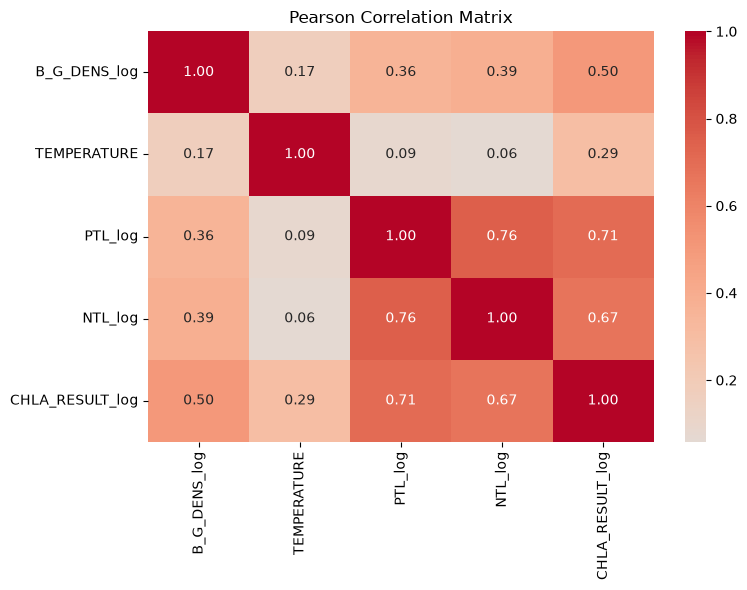

In [26]:
# Let's visualize it:

plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

### Then I'll do Spearman
### 

In [27]:
spearman_corr = df[corr_vars].corr(method='spearman')

spearman_corr

,B_G_DENS_log,TEMPERATURE,PTL_log,NTL_log,CHLA_RESULT_log
B_G_DENS_log,1.000000,0.123606,0.405714,0.468527,0.532782
TEMPERATURE,0.123606,1.000000,0.097772,0.148452,0.310158
PTL_log,0.405714,0.097772,1.000000,0.789308,0.725751
NTL_log,0.468527,0.148452,0.789308,1.000000,0.707617
CHLA_RESULT_log,0.532782,0.310158,0.725751,0.707617,1.000000


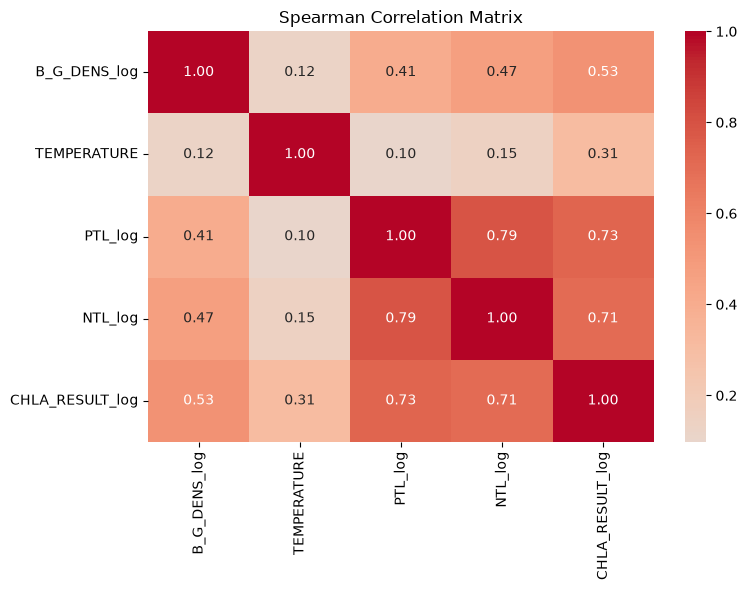

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

###  I have used these to correlation measures for two purposes:

### 1- Pearson asks roughly:

#### Is there a linear relationship?


### 2- Spearman asks:

#### Do the variables generally increase or decrease together, even if the relationship isn't linear?

#### Because NTL remains strongly skewed and B_G_DENS has extreme observations, Spearman may give us a more robust picture of the relationships

### so this is particularly useful for dataset.

### So, the result from the matrix above produced several important observations about the four variables, chlorophyll-a has the strongest association with cyanobacteria density, followed by nitrogen and phosphorus. Temperature has only a weak association. Table below shows the relationship between the fourth variables and cyanobacteria density.

### There is another important finding in your matrices: the predictors themselves are correlated. For example, Pearson gives PTL_log–NTL_log = 0.76 and PTL_log–CHLA_RESULT_log = 0.71. Spearman gives similar results. This is worth mentioning because if I later build a regression model, multicollinearity will need to be considered.

### Also notice that Pearson and Spearman give broadly similar conclusions. That's encouraging: the relationships aren't appearing only because of a few extreme observations.

| Variable vs `B_G_DENS_log` |  Pearson | Spearman | Interpretation                  |
| -------------------------- | -------: | -------: | ------------------------------- |
| `TEMPERATURE`              |     0.17 |     0.12 | Weak positive                   |
| `PTL_log`                  |     0.36 |     0.41 | Moderate positive               |
| `NTL_log`                  |     0.39 |     0.47 | Moderate positive               |
| `CHLA_RESULT_log`          | **0.50** | **0.53** | Strongest positive relationship |


### Next step is Scatter Plot which will help to get a clear picture: I will start with the strongest one

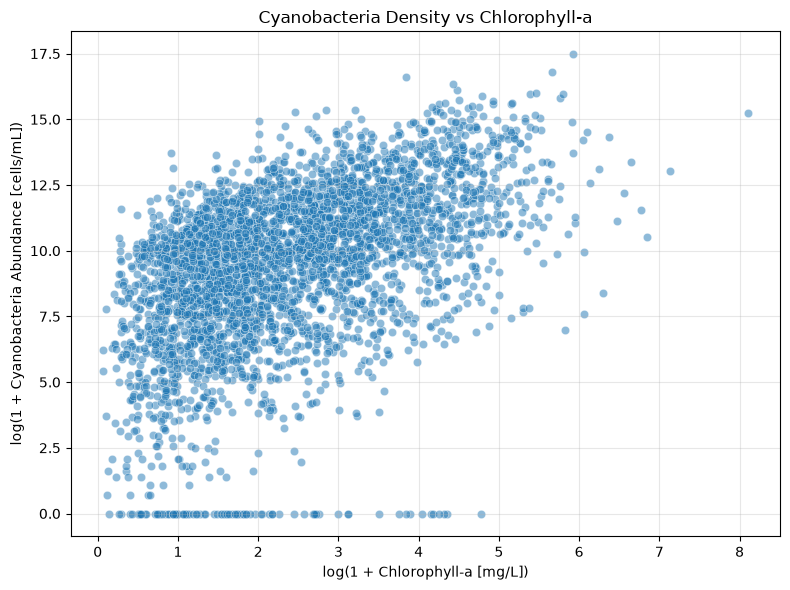

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='CHLA_RESULT_log',
    y='B_G_DENS_log',
    alpha=0.5
)

plt.title('Cyanobacteria Density vs Chlorophyll-a')
plt.xlabel('log(1 + Chlorophyll-a [mg/L])')
plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

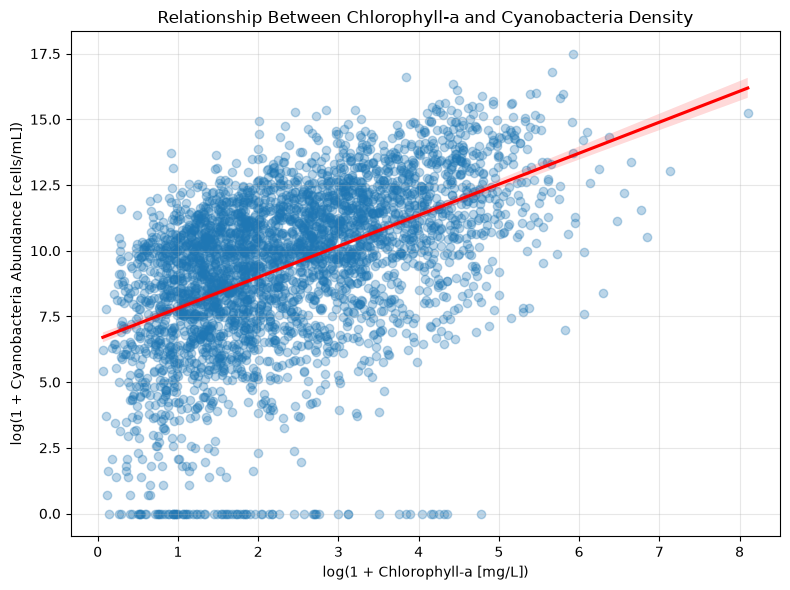

In [30]:

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='CHLA_RESULT_log',
    y='B_G_DENS_log',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between Chlorophyll-a and Cyanobacteria Density')
plt.xlabel('log(1 + Chlorophyll-a [mg/L])')
plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation: The scatter plot indicates a moderate positive association between chlorophyll-a and cyanobacteria density. Higher chlorophyll-a concentrations generally correspond to higher cyanobacteria density. This is consistent with the Pearson (r = 0.50) and Spearman (ρ = 0.53) correlation coefficients. However, substantial variability remains, indicating that chlorophyll-a alone does not fully explain variation in cyanobacteria density.

### Next, I will investigate the other three variables

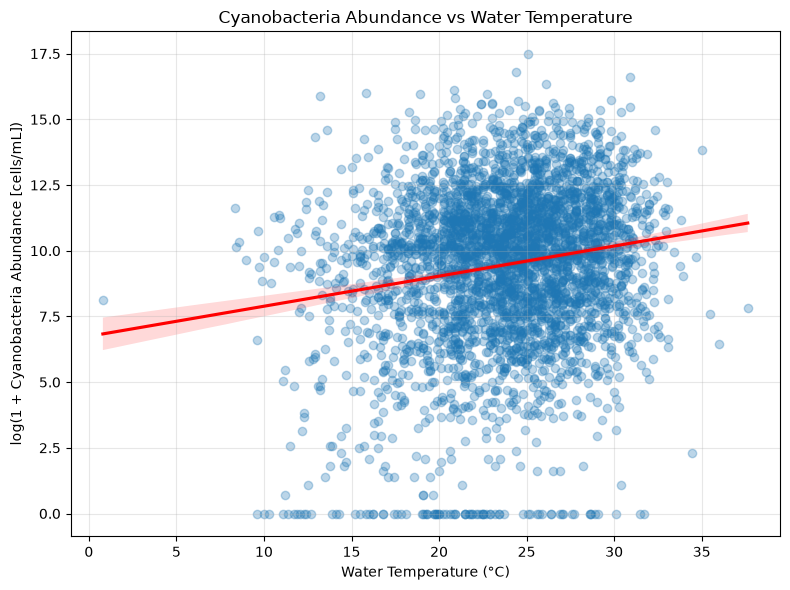

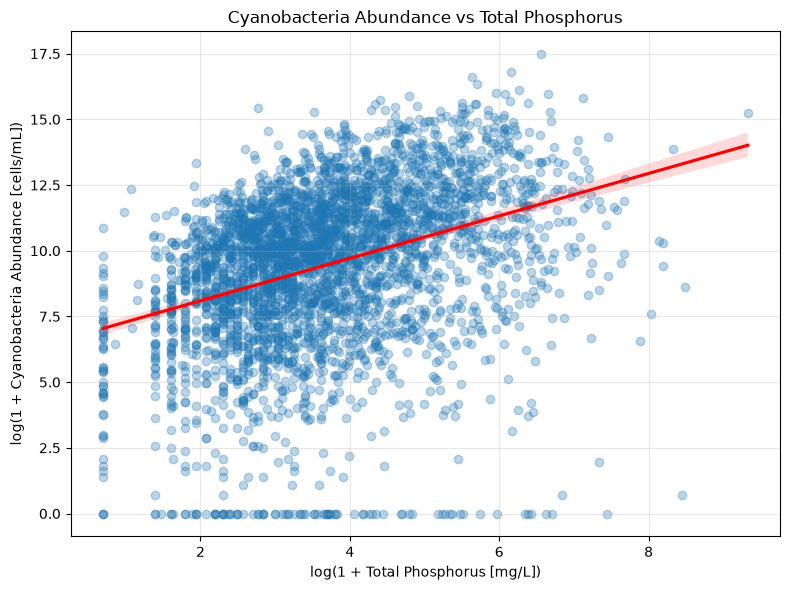

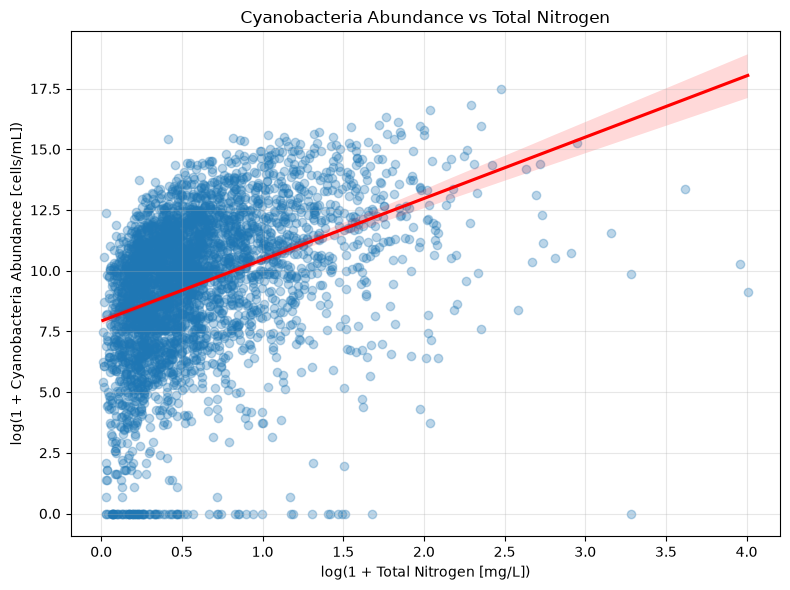

In [31]:
# Variables to plot
variables = [
    'TEMPERATURE',
    'PTL_log',
    'NTL_log'
]

# Professional names for each variable
labels = {
    'TEMPERATURE': 'Water Temperature (°C)',
    'PTL_log': 'log(1 + Total Phosphorus [mg/L])',
    'NTL_log': 'log(1 + Total Nitrogen [mg/L])'
}

# Names to use in plot titles
titles = {
    'TEMPERATURE': 'Water Temperature',
    'PTL_log': 'Total Phosphorus',
    'NTL_log': 'Total Nitrogen'
}

for variable in variables:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y='B_G_DENS_log',
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )

    plt.title(f'Cyanobacteria Abundance vs {titles[variable]}')

    plt.xlabel(labels[variable])

    plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### As expected: These three plots are consistent with the correlation matrices, and they provide a clearer picture of the relationships.

### Temperature → Cyanobacteria density: The regression line slopes upward, but the points are very widely scattered. This supports the weak Pearson correlation of 0.17. Temperature alone has only a weak positive association with cyanobacteria density in these observations.

### Total phosphorus (PTL_log) → Cyanobacteria density: There is a much clearer upward trend. This agrees with Pearson r = 0.36 and Spearman ρ = 0.41. I'd describe this as a moderate positive association.

### Total nitrogen (NTL_log) → Cyanobacteria density: This also shows a noticeable positive relationship and appears somewhat stronger than phosphorus, consistent with Pearson r = 0.39 and Spearman ρ = 0.47. Again, a moderate positive association.


### Combined with your chlorophyll-a result, your ranking is therefore:

### Chlorophyll-a (0.50) > Nitrogen (0.39) > Phosphorus (0.36) > Temperature (0.17) using Pearson correlation.

## Conclusion: 
The exploratory analysis indicates that cyanobacteria abundance is positively associated with chlorophyll-a, total nitrogen, total phosphorus, and water temperature. Chlorophyll-a showed the strongest association with cyanobacteria abundance, followed by total nitrogen and total phosphorus, while temperature showed only a weak positive relationship. Log transformations improved the distributions of several highly skewed environmental variables and made the relationships easier to visualise. These findings describe associations rather than causal relationships. Future work will extend this analysis using regression modelling to investigate the combined contribution of the environmental predictors to cyanobacteria abundance.

## Future Work

The next stage of this project will develop regression models to predict cyanobacteria abundance using environmental variables such as temperature, total phosphorus, total nitrogen, and chlorophyll-a. Model assumptions, multicollinearity, performance metrics, and validation will also be investigated.

In [32]:
import os

for root, dirs, files in os.walk(".."):
    level = root.replace("..", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

../
    .gitignore
    README.md
    .git/
        config
        description
        HEAD
        index
        packed-refs
        hooks/
            applypatch-msg.sample
            commit-msg.sample
            fsmonitor-watchman.sample
            post-update.sample
            pre-applypatch.sample
            pre-commit.sample
            pre-merge-commit.sample
            pre-push.sample
            pre-rebase.sample
            pre-receive.sample
            prepare-commit-msg.sample
            push-to-checkout.sample
            sendemail-validate.sample
            update.sample
        info/
            exclude
        logs/
            HEAD
            refs/
                heads/
                    main
                remotes/
                    origin/
                        HEAD
        objects/
            info/
            pack/
                pack-cd750988b8820a18a822412414f6e51aa39f719c.idx
                pack-cd750988b8820a18a822412414f6e51aa39f719c.pack
 

In [33]:
print('done')

done
